In [1]:
# load dotenv FIRST — JAX reads JAX_COMPILATION_CACHE_DIR once at import time,
# and tools.loader transitively imports JAX, so dotenv must run before any tools.* import.
from dotenv import load_dotenv
import os
load_dotenv()

# Add one dir up to path
import sys
sys.path.append('../')
from tools.loader import build_deposit_data
from tools.particle_generator import generate_muon_track

In [2]:
from tools.geometry import generate_detector
from tools.simulation import DetectorSimulator

detector_config = generate_detector('../config/cubic_wireplane_config.yaml')
simulator = DetectorSimulator(detector_config)
sim_config = simulator.config

--- Creating DetectorSimulator ---
   Extracting parameters...


E0421 15:04:22.638172   62824 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0421 15:04:22.653709   62746 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=200,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Track labeling: ENABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---


In [3]:
track = generate_muon_track(
    start_position_mm=(0.0, 0.0, 0.0),
    direction=(1, 1, 1),
    kinetic_energy_mev=1000.0,
    step_size_mm=0.1,
    track_id=1,
    detector_bounds_mm=((-300, 300), (-300, 300), (-300, 300)),
)

deposits = build_deposit_data(
    track['position'], track['de'], track['dx'], sim_config,
    theta=track['theta'], phi=track['phi'],
    track_ids=track['track_id'],
)

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  USER CONFIG  — edit this cell
# ══════════════════════════════════════════════════════════════════════════════

VARY_PARAM = 'velocity'        # 'lifetime'  or  'velocity'
GT_LIFETIME_US    = 10_000.0   # μs       (ground truth)
GT_VELOCITY_CM_US = 0.160      # cm/μs    (ground truth)
TEST_FACTOR = 1.2              # multiplicative offset from GT for the test point (e.g. 1.2 = +20%)

In [5]:
import jax
import jax.numpy as jnp
import numpy as np
from tools.losses import sobolev_loss_single, make_sobolev_weight

SOBOLEV_MAX_PAD = 128

diff_simulator = DetectorSimulator(
    detector_config,
    differentiable=True,
    n_segments=10_000,
    use_bucketed=True,
    max_active_buckets=1000,
    include_noise=False,
    include_electronics=False,
    include_track_hits=False,
    include_digitize=False,
    track_config=None,
)
diff_simulator.warm_up()

base_params = diff_simulator.default_sim_params
gt_params = base_params._replace(
    lifetime_us    = jnp.array(GT_LIFETIME_US),
    velocity_cm_us = jnp.array(GT_VELOCITY_CM_US),
)

# ── Single-parameter forward function ─────────────────────────────────────────
# p_n is a scalar: the varied parameter normalised by its GT value (GT = 1.0).
if VARY_PARAM == 'lifetime':
    def _make_params(p_n):
        return gt_params._replace(lifetime_us=p_n * GT_LIFETIME_US)
    param_label = 'lifetime'
    param_unit  = 'μs'
    param_gt    = GT_LIFETIME_US
elif VARY_PARAM == 'velocity':
    def _make_params(p_n):
        return gt_params._replace(velocity_cm_us=p_n * GT_VELOCITY_CM_US)
    param_label = 'velocity'
    param_unit  = 'cm/μs'
    param_gt    = GT_VELOCITY_CM_US
else:
    raise ValueError(f"VARY_PARAM must be 'lifetime' or 'velocity', got {VARY_PARAM!r}")

fwd_fn = jax.jit(lambda p_n: diff_simulator.forward(_make_params(p_n), deposits))

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=10,000, response_chunk=10,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Triggering JIT compilation...


W0421 15:04:26.645433   62746 pjrt_executable.cc:642] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


JIT compilation finished (total_pad=10,000, iterate=scan).


In [6]:
gt_arrays = diff_simulator.forward(gt_params, deposits)
jax.block_until_ready(gt_arrays)

weights = tuple(
    make_sobolev_weight(arr.shape[0], arr.shape[1], max_pad=SOBOLEV_MAX_PAD)
    for arr in gt_arrays
)

def loss_fn(p_n):
    pred = fwd_fn(p_n)
    return jnp.sum(jnp.array([
        sobolev_loss_single(pr, gt, w)
        for pr, gt, w in zip(pred, gt_arrays, weights)
    ]))

value_and_grad = jax.jit(jax.value_and_grad(loss_fn))

W0421 15:04:27.877055   62746 pjrt_executable.cc:642] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


In [7]:
import time

p_n = jnp.array(0.99)   # close to GT (= 1.0) for timing

# Warm up
_ = fwd_fn(p_n);                      jax.block_until_ready(_)
loss_val, grad = value_and_grad(p_n); jax.block_until_ready(loss_val)

t0 = time.perf_counter()
out = fwd_fn(p_n); jax.block_until_ready(out)
t_fwd = time.perf_counter() - t0

t0 = time.perf_counter()
out = value_and_grad(p_n); jax.block_until_ready(out)
t_fwd_grad = time.perf_counter() - t0

print(f"Forward pass time:       {t_fwd*1e3:.1f} ms")
print(f"Forward + gradient time: {t_fwd_grad*1e3:.1f} ms  ({t_fwd_grad/t_fwd:.2f}x)")
print(f"Loss at p_n=0.99:        {float(loss_val):.4e}")
print(f"∂loss/∂{param_label}_n at p_n=0.99: {float(grad):.4e}")

W0421 15:04:29.314541   62746 pjrt_executable.cc:642] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Forward pass time:       20.2 ms
Forward + gradient time: 189.5 ms  (9.38x)
Loss at p_n=0.99:        4.5205e+03
∂loss/∂velocity_n at p_n=0.99: -9.0406e+05


In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tools.visualization import (
    _extract_viz_params, _resolve_cmap, _add_colorbar,
    _plane_norm_key, _plane_type, _vol_name, DeadbandNorm,
)

VOL = 1
cfg = diff_simulator.config
n_planes = cfg.volumes[VOL].n_planes

plane_keys = [
    (v, p)
    for v in range(cfg.n_volumes)
    for p in range(cfg.volumes[v].n_planes)
]

vp        = _extract_viz_params(cfg)
num_time  = vp['num_time_steps']
time_step = vp['time_step_us']
num_wires = vp['num_wires']
max_time  = num_time * time_step
gamma         = 0.2
threshold_enc = 0
deadband_adc  = threshold_enc / vp['electrons_per_adc']

# ── Forward passes ─────────────────────────────────────────────────────────────
test_p_n    = jnp.array(TEST_FACTOR)
pred_arrays = fwd_fn(test_p_n)
jax.block_until_ready(pred_arrays)

# Directional derivative at the test point, tangent = +1 (increasing param)
_, tangents = jax.jvp(fwd_fn, (test_p_n,), (jnp.array(1.0),))
jax.block_until_ready(tangents)

gt_dict      = {k: np.asarray(a)     for k, a      in zip(plane_keys, gt_arrays)}
pred_dict    = {k: np.asarray(a)     for k, a      in zip(plane_keys, pred_arrays)}
diff_dict    = {k: np.asarray(g - p) for k, (p, g) in zip(plane_keys, zip(pred_arrays, gt_arrays))}
tangent_dict = {k: np.asarray(t)     for k, t      in zip(plane_keys, tangents)}

test_val      = float(test_p_n) * param_gt
overlay_title = f'Difference  +  d/d({param_label}_n)  at factor={TEST_FACTOR}'
PLANE_LETTERS = {0: 'U', 1: 'V', 2: 'Y'}

# ── Per-plane axis limits: union of nonzero bounding boxes across all signal dicts ──
_all_signals = [gt_dict, pred_dict, diff_dict, tangent_dict]
MARGIN = 0.04
plane_xlim = {}
plane_ylim = {}
for col_idx in range(n_planes):
    key = (VOL, col_idx)
    w0_all, w1_all, t0_all, t1_all = np.inf, -np.inf, np.inf, -np.inf
    for signals in _all_signals:
        arr     = np.asarray(signals[key])
        mask    = arr != 0
        wire_nz = np.where(mask.any(axis=1))[0]
        time_nz = np.where(mask.any(axis=0))[0]
        if len(wire_nz) and len(time_nz):
            w0_all = min(w0_all, float(wire_nz[0]))
            w1_all = max(w1_all, float(wire_nz[-1] + 1))
            t0_all = min(t0_all, float(time_nz[0]))
            t1_all = max(t1_all, float(time_nz[-1] + 1))
    if w1_all > w0_all:
        t0_us, t1_us = t0_all * time_step, t1_all * time_step
        wx = (w1_all - w0_all) * MARGIN
        tx = (t1_us  - t0_us)  * MARGIN
        plane_xlim[col_idx] = (max(0.0, w0_all - wx), w1_all + wx)
        plane_ylim[col_idx] = (max(0.0, t0_us  - tx), min(max_time, t1_us + tx))
    else:
        plane_xlim[col_idx] = (0, max(s[key].shape[0] for s in _all_signals))
        plane_ylim[col_idx] = (0, max_time)

def _plane_ranges_for_row(signals, cmap_name):
    plane_ranges = {'U-plane': [np.inf, -np.inf],
                    'V-plane': [np.inf, -np.inf],
                    'Y-plane': [np.inf, -np.inf]}
    for p in range(n_planes):
        key = (VOL, p)
        if key in signals:
            vals  = signals[key].ravel()
            pname = _plane_norm_key(p)
            if len(vals):
                plane_ranges[pname][0] = min(plane_ranges[pname][0], vals.min())
                plane_ranges[pname][1] = max(plane_ranges[pname][1], vals.max())
    for pname, (vmin, vmax) in plane_ranges.items():
        if vmin == np.inf:
            plane_ranges[pname] = [-25, 25]
        elif cmap_name == 'RdBu_r':
            m = max(abs(vmin), abs(vmax))
            plane_ranges[pname] = [-m, m]
    return plane_ranges

def _make_alpha_diverging_cmap(base_name='PiYG', n=256):
    base = mcolors.LinearSegmentedColormap.from_list(
        base_name, plt.colormaps[base_name](np.linspace(0, 1, n))
    )
    colors = base(np.linspace(0, 1, n))
    colors[:, 3] = np.abs(np.linspace(-1, 1, n))
    return mcolors.ListedColormap(colors)

_TANG_CMAP = _make_alpha_diverging_cmap('PiYG')

def _draw_row(fig, gs_row, signals, cmap_name, row_title, row_gs_idx=None):
    resolved_cmap = _resolve_cmap(cmap_name)
    zero_color    = resolved_cmap(0.5)
    plane_ranges  = _plane_ranges_for_row(signals, cmap_name)

    for col_idx in range(n_planes):
        ax  = fig.add_subplot(gs_row[col_idx] if row_gs_idx is None else gs_row[row_gs_idx, col_idx])
        key = (VOL, col_idx)
        ax.set_facecolor(zero_color)
        ax.grid(False)

        pname      = _plane_norm_key(col_idx)
        vmin, vmax = plane_ranges[pname]
        norm       = DeadbandNorm(vmin, vmax, deadband_adc, gamma)

        arr = np.asarray(signals[key])
        im  = ax.imshow(arr.T, aspect='auto', origin='lower',
                        extent=[0, arr.shape[0], 0, max_time],
                        cmap=resolved_cmap, norm=norm,
                        interpolation='nearest')
        _add_colorbar(fig, ax, im, norm)

        ax.set_xlim(*plane_xlim[col_idx])
        ax.set_ylim(*plane_ylim[col_idx])
        ax.set_box_aspect(1)

        plane_letter = PLANE_LETTERS.get(col_idx, f'Plane {col_idx}')
        ax.set_title(f'{plane_letter} — {row_title}', fontsize=12, pad=8)
        ax.set_xlabel('Wire Index', fontsize=11)
        ax.set_ylabel('Time (μs)', fontsize=11)


RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'results')

def make_plots(rows, results_dir, filename_prefix):
    """Save the overview figure and one PDF per row to results_dir.

    Parameters
    ----------
    rows : list of (signals_dict, cmap_name, row_title, file_tag)
    results_dir : str
    filename_prefix : str  e.g. 'sobolev_loss'
    """
    os.makedirs(results_dir, exist_ok=True)
    n_rows = len(rows)

    # Combined overview
    fig = plt.figure(figsize=(7 * n_planes, 6 * n_rows), facecolor='white')
    gs  = gridspec.GridSpec(n_rows, n_planes, figure=fig, hspace=0.40, wspace=0.35)
    for row_idx, (signals, cmap_name, row_title, _) in enumerate(rows):
        _draw_row(fig, gs, signals, cmap_name, row_title, row_gs_idx=row_idx)
    overview_path = os.path.join(results_dir, f'{filename_prefix}_overview_{param_label}.pdf')
    fig.savefig(overview_path, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved: {overview_path}')

    # Per-row PDFs
    for signals, cmap_name, row_title, file_tag in rows:
        fig_row = plt.figure(figsize=(7 * n_planes, 6), facecolor='white')
        gs_row  = gridspec.GridSpec(1, n_planes, figure=fig_row, hspace=0.40, wspace=0.35)
        _draw_row(fig_row, gs_row, signals, cmap_name, row_title)
        pdf_path = os.path.join(results_dir, f'{filename_prefix}_{file_tag}_{param_label}.pdf')
        fig_row.savefig(pdf_path, bbox_inches='tight')
        plt.close(fig_row)
        print(f'Saved: {pdf_path}')


def make_interactive_plot(diff_d, tang_d, results_dir, filename_prefix):
    """Build the interactive diff+derivative Plotly figure and save as HTML.

    Parameters
    ----------
    diff_d, tang_d : dict  {(vol, plane): np.ndarray}
    results_dir : str
    filename_prefix : str  e.g. 'sobolev_loss'
    """
    diff_max = max(
        max(abs(diff_d[(VOL, p)].min()), abs(diff_d[(VOL, p)].max()))
        for p in range(n_planes)
    )
    tang_max = max(
        max(abs(tang_d[(VOL, p)].min()), abs(tang_d[(VOL, p)].max()))
        for p in range(n_planes)
    )

    fig_i = make_subplots(
        rows=1, cols=n_planes,
        subplot_titles=[PLANE_LETTERS.get(i, f'Plane {i}') for i in range(n_planes)],
        horizontal_spacing=0.10,
    )

    for col_idx in range(n_planes):
        key = (VOL, col_idx)
        arr = diff_d[key]
        x   = np.arange(arr.shape[0])
        y   = np.arange(arr.shape[1]) * time_step
        fig_i.add_trace(
            go.Heatmap(
                z=arr.T, x=x, y=y,
                coloraxis='coloraxis', opacity=1.0,
                name=f'Diff {PLANE_LETTERS.get(col_idx, col_idx)}',
                hovertemplate='Wire: %{x}<br>Time: %{y:.2f} μs<br>ADC: %{z:.1f}<extra></extra>',
            ),
            row=1, col=col_idx + 1,
        )

    for col_idx in range(n_planes):
        key = (VOL, col_idx)
        arr = tang_d[key]
        x   = np.arange(arr.shape[0])
        y   = np.arange(arr.shape[1]) * time_step
        fig_i.add_trace(
            go.Heatmap(
                z=arr.T, x=x, y=y,
                coloraxis='coloraxis2', opacity=0.5,
                name=f'Deriv {PLANE_LETTERS.get(col_idx, col_idx)}',
                hovertemplate='Wire: %{x}<br>Time: %{y:.2f} μs<br>d/d: %{z:.4f}<extra></extra>',
            ),
            row=1, col=col_idx + 1,
        )

    for col_idx in range(n_planes):
        xax = 'xaxis' if col_idx == 0 else f'xaxis{col_idx + 1}'
        yax = 'yaxis' if col_idx == 0 else f'yaxis{col_idx + 1}'
        fig_i.update_layout(**{
            xax: dict(range=list(plane_xlim[col_idx]), title='Wire Index'),
            yax: dict(range=list(plane_ylim[col_idx]), title='Time (μs)'),
        })

    N_STEPS      = 21
    opacity_vals = [round(i / (N_STEPS - 1), 2) for i in range(N_STEPS)]
    diff_idx     = list(range(n_planes))
    tang_idx     = list(range(n_planes, 2 * n_planes))

    sliders = [
        dict(
            active=N_STEPS - 1,
            currentvalue=dict(prefix='Difference opacity: ', font=dict(size=13)),
            pad=dict(t=10), len=0.88, x=0.06, y=0.0, yanchor='top',
            steps=[dict(method='restyle', args=[{'opacity': op}, diff_idx],
                        label=f'{op:.2f}') for op in opacity_vals],
        ),
        dict(
            active=N_STEPS // 2,
            currentvalue=dict(prefix='Derivative opacity: ', font=dict(size=13)),
            pad=dict(t=10), len=0.88, x=0.06, y=-0.12, yanchor='top',
            steps=[dict(method='restyle', args=[{'opacity': op}, tang_idx],
                        label=f'{op:.2f}') for op in opacity_vals],
        ),
    ]

    fig_i.update_layout(
        title_text=overlay_title,
        height=560,
        margin=dict(b=180, r=120),
        paper_bgcolor='white',
        coloraxis=dict(
            colorscale='RdBu_r', cmid=0, cmin=-diff_max, cmax=diff_max,
            colorbar=dict(title='Diff (ADC)', x=1.02, len=0.85, y=0.5),
        ),
        coloraxis2=dict(
            colorscale='PiYG', cmid=0, cmin=-tang_max, cmax=tang_max,
            colorbar=dict(title=f'd/d({param_label}_n)', x=1.12, len=0.85, y=0.5),
        ),
        sliders=sliders,
    )

    os.makedirs(results_dir, exist_ok=True)
    html_path = os.path.join(results_dir, f'{filename_prefix}_interactive_{param_label}.html')
    fig_i.write_html(html_path, include_plotlyjs='cdn')
    print(f'Saved: {html_path}')


W0421 15:05:02.790068   62746 pjrt_executable.cc:642] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


In [9]:
# ── Sobolev loss ──────────────────────────────────────────────────────────────
loss_val_sobolev, grad_sobolev = value_and_grad(test_p_n)
jax.block_until_ready(loss_val_sobolev)
print(f'sobolev_loss={float(loss_val_sobolev):.4e},  grad={float(grad_sobolev):.4e}')

rows_sobolev = [
    (gt_dict,      'obsidian', f'GT  ({param_label}={param_gt:.4g} {param_unit})', 'gt'),
    (pred_dict,    'obsidian', (f'Pred  ({param_label}={test_val:.4g} {param_unit},  ×{TEST_FACTOR})'
                                f'  |  sobolev_loss={float(loss_val_sobolev):.3e}'), 'prediction'),
    (diff_dict,    'RdBu_r',   'Difference  (pred − GT)', 'difference'),
    (tangent_dict, 'RdBu_r',   f'd/d({param_label}_n) at factor={TEST_FACTOR}', 'derivative'),
]

make_plots(rows_sobolev, RESULTS_DIR, 'sobolev_loss')
make_interactive_plot(diff_dict, tangent_dict, RESULTS_DIR, 'sobolev_loss')


sobolev_loss=3.9663e+05,  grad=5.6087e+05
Saved: /home/gregor/JAXTPC/results/sobolev_loss_overview_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_gt_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_prediction_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_difference_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_derivative_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_interactive_velocity.html


In [10]:
# ── sobolev_loss_geomean_log1p ────────────────────────────────────────────────
from tools.losses import sobolev_loss_geomean_log1p

def _loss_fn_geomean_log1p(p_n):
    pred = fwd_fn(p_n)
    return sobolev_loss_geomean_log1p(pred, gt_arrays, weights)

val_and_grad_geomean = jax.jit(jax.value_and_grad(_loss_fn_geomean_log1p))

# Warm up
_ = val_and_grad_geomean(jnp.array(0.99)); jax.block_until_ready(_)

loss_val_geomean, grad_geomean = val_and_grad_geomean(test_p_n)
jax.block_until_ready(loss_val_geomean)
print(f'geomean_log1p={float(loss_val_geomean):.4e},  grad={float(grad_geomean):.4e}')

rows_geomean = [
    (gt_dict,      'obsidian', f'GT  ({param_label}={param_gt:.4g} {param_unit})', 'gt'),
    (pred_dict,    'obsidian', (f'Pred  ({param_label}={test_val:.4g} {param_unit},  ×{TEST_FACTOR})'
                                f'  |  geomean_log1p={float(loss_val_geomean):.3e}'), 'prediction'),
    (diff_dict,    'RdBu_r',   'Difference  (pred − GT)', 'difference'),
    (tangent_dict, 'RdBu_r',   f'd/d({param_label}_n) at factor={TEST_FACTOR}', 'derivative'),
]

make_plots(rows_geomean, RESULTS_DIR, 'sobolev_loss_geomean_log1p')
make_interactive_plot(diff_dict, tangent_dict, RESULTS_DIR, 'sobolev_loss_geomean_log1p')


geomean_log1p=2.1276e+02,  grad=2.3940e+01
Saved: /home/gregor/JAXTPC/results/sobolev_loss_geomean_log1p_overview_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_geomean_log1p_gt_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_geomean_log1p_prediction_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_geomean_log1p_difference_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_geomean_log1p_derivative_velocity.pdf
Saved: /home/gregor/JAXTPC/results/sobolev_loss_geomean_log1p_interactive_velocity.html


In [11]:
# ── sobolev_loss_geomean_log1p: image movement under gradient descent ──────────
# Δoutput ≈ -lr * (∂L/∂param) * (∂output/∂param)
# The direction is: -grad_geomean * JVP_tangent  (lr cancels as it is just a scale)

movement_dict = {k: -float(grad_geomean) * tangent_dict[k] for k in tangent_dict}

movement_max = max(
    max(abs(movement_dict[(VOL, p)].min()), abs(movement_dict[(VOL, p)].max()))
    for p in range(n_planes)
)
diff_max_mv = max(
    max(abs(diff_dict[(VOL, p)].min()), abs(diff_dict[(VOL, p)].max()))
    for p in range(n_planes)
)

fig_mv = make_subplots(
    rows=1, cols=n_planes,
    subplot_titles=[PLANE_LETTERS.get(i, f'Plane {i}') for i in range(n_planes)],
    horizontal_spacing=0.10,
)

for col_idx in range(n_planes):
    key = (VOL, col_idx)
    arr = diff_dict[key]
    x = np.arange(arr.shape[0])
    y = np.arange(arr.shape[1]) * time_step
    fig_mv.add_trace(
        go.Heatmap(
            z=arr.T, x=x, y=y,
            coloraxis='coloraxis', opacity=1.0,
            name=f'Diff {PLANE_LETTERS.get(col_idx, col_idx)}',
            hovertemplate='Wire: %{x}<br>Time: %{y:.2f} μs<br>Diff: %{z:.2f}<extra></extra>',
        ),
        row=1, col=col_idx + 1,
    )

for col_idx in range(n_planes):
    key = (VOL, col_idx)
    arr = movement_dict[key]
    x = np.arange(arr.shape[0])
    y = np.arange(arr.shape[1]) * time_step
    fig_mv.add_trace(
        go.Heatmap(
            z=arr.T, x=x, y=y,
            coloraxis='coloraxis2', opacity=0.5,
            name=f'Δoutput {PLANE_LETTERS.get(col_idx, col_idx)}',
            hovertemplate='Wire: %{x}<br>Time: %{y:.2f} μs<br>Δoutput: %{z:.4e}<extra></extra>',
        ),
        row=1, col=col_idx + 1,
    )

for col_idx in range(n_planes):
    xax = 'xaxis' if col_idx == 0 else f'xaxis{col_idx + 1}'
    yax = 'yaxis' if col_idx == 0 else f'yaxis{col_idx + 1}'
    fig_mv.update_layout(**{
        xax: dict(range=list(plane_xlim[col_idx]), title='Wire Index'),
        yax: dict(range=list(plane_ylim[col_idx]), title='Time (μs)'),
    })

N_STEPS      = 21
opacity_vals = [round(i / (N_STEPS - 1), 2) for i in range(N_STEPS)]
diff_idx_mv  = list(range(n_planes))
move_idx     = list(range(n_planes, 2 * n_planes))

fig_mv.update_layout(
    title_text=f'Difference + Δoutput under grad descent  (geomean_log1p, grad={float(grad_geomean):.3e})  factor={TEST_FACTOR}',
    height=560,
    margin=dict(b=180, r=140),
    paper_bgcolor='white',
    coloraxis=dict(
        colorscale='RdBu_r', cmid=0, cmin=-diff_max_mv, cmax=diff_max_mv,
        colorbar=dict(title='Diff (ADC)', x=1.02, len=0.85, y=0.5),
    ),
    coloraxis2=dict(
        colorscale='PiYG', cmid=0, cmin=-movement_max, cmax=movement_max,
        colorbar=dict(title='Δoutput', x=1.14, len=0.85, y=0.5),
    ),
    sliders=[
        dict(
            active=N_STEPS - 1,
            currentvalue=dict(prefix='Difference opacity: ', font=dict(size=13)),
            pad=dict(t=10), len=0.88, x=0.06, y=0.0, yanchor='top',
            steps=[dict(method='restyle', args=[{'opacity': op}, diff_idx_mv],
                        label=f'{op:.2f}') for op in opacity_vals],
        ),
        dict(
            active=N_STEPS // 2,
            currentvalue=dict(prefix='Δoutput opacity: ', font=dict(size=13)),
            pad=dict(t=10), len=0.88, x=0.06, y=-0.12, yanchor='top',
            steps=[dict(method='restyle', args=[{'opacity': op}, move_idx],
                        label=f'{op:.2f}') for op in opacity_vals],
        ),
    ],
)

plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'plots')
os.makedirs(plots_dir, exist_ok=True)
html_path = os.path.join(plots_dir, 'sobolev_loss_log1p_interactive_overlaid.html')
fig_mv.write_html(html_path, include_plotlyjs='cdn')
print(f'Saved: {html_path}')
print(f'grad_geomean={float(grad_geomean):.4e}  →  image moves {"with" if grad_geomean > 0 else "against"} the JVP tangent')


Saved: /home/gregor/JAXTPC/plots/sobolev_loss_log1p_interactive_overlaid.html
grad_geomean=2.3940e+01  →  image moves with the JVP tangent


In [12]:
# ── GT vs Pred interactive overlay ────────────────────────────────────────────
# Stacks GT and Pred images with independent opacity sliders.

gt_max = max(
    max(abs(gt_dict[(VOL, p)].min()), abs(gt_dict[(VOL, p)].max()))
    for p in range(n_planes)
)
pred_max = max(
    max(abs(pred_dict[(VOL, p)].min()), abs(pred_dict[(VOL, p)].max()))
    for p in range(n_planes)
)
shared_max = max(gt_max, pred_max)

fig_gp = make_subplots(
    rows=1, cols=n_planes,
    subplot_titles=[PLANE_LETTERS.get(i, f'Plane {i}') for i in range(n_planes)],
    horizontal_spacing=0.10,
)

for col_idx in range(n_planes):
    key = (VOL, col_idx)
    arr = gt_dict[key]
    x = np.arange(arr.shape[0])
    y = np.arange(arr.shape[1]) * time_step
    fig_gp.add_trace(
        go.Heatmap(
            z=arr.T, x=x, y=y,
            coloraxis='coloraxis', opacity=1.0,
            name=f'GT {PLANE_LETTERS.get(col_idx, col_idx)}',
            hovertemplate='Wire: %{x}<br>Time: %{y:.2f} μs<br>GT: %{z:.2f}<extra></extra>',
        ),
        row=1, col=col_idx + 1,
    )

for col_idx in range(n_planes):
    key = (VOL, col_idx)
    arr = pred_dict[key]
    x = np.arange(arr.shape[0])
    y = np.arange(arr.shape[1]) * time_step
    fig_gp.add_trace(
        go.Heatmap(
            z=arr.T, x=x, y=y,
            coloraxis='coloraxis2', opacity=0.5,
            name=f'Pred {PLANE_LETTERS.get(col_idx, col_idx)}',
            hovertemplate='Wire: %{x}<br>Time: %{y:.2f} μs<br>Pred: %{z:.2f}<extra></extra>',
        ),
        row=1, col=col_idx + 1,
    )

for col_idx in range(n_planes):
    xax = 'xaxis' if col_idx == 0 else f'xaxis{col_idx + 1}'
    yax = 'yaxis' if col_idx == 0 else f'yaxis{col_idx + 1}'
    fig_gp.update_layout(**{
        xax: dict(range=list(plane_xlim[col_idx]), title='Wire Index'),
        yax: dict(range=list(plane_ylim[col_idx]), title='Time (μs)'),
    })

N_STEPS      = 21
opacity_vals = [round(i / (N_STEPS - 1), 2) for i in range(N_STEPS)]
gt_idx       = list(range(n_planes))
pred_idx     = list(range(n_planes, 2 * n_planes))

fig_gp.update_layout(
    title_text=f'GT vs Pred  ({param_label} factor={TEST_FACTOR})',
    height=560,
    margin=dict(b=180, r=140),
    paper_bgcolor='white',
    coloraxis=dict(
        colorscale='Viridis', cmin=0, cmax=shared_max,
        colorbar=dict(title='GT (ADC)', x=1.02, len=0.85, y=0.5),
    ),
    coloraxis2=dict(
        colorscale='Plasma', cmin=0, cmax=shared_max,
        colorbar=dict(title='Pred (ADC)', x=1.14, len=0.85, y=0.5),
    ),
    sliders=[
        dict(
            active=N_STEPS - 1,
            currentvalue=dict(prefix='GT opacity: ', font=dict(size=13)),
            pad=dict(t=10), len=0.88, x=0.06, y=0.0, yanchor='top',
            steps=[dict(method='restyle', args=[{'opacity': op}, gt_idx],
                        label=f'{op:.2f}') for op in opacity_vals],
        ),
        dict(
            active=N_STEPS // 2,
            currentvalue=dict(prefix='Pred opacity: ', font=dict(size=13)),
            pad=dict(t=10), len=0.88, x=0.06, y=-0.12, yanchor='top',
            steps=[dict(method='restyle', args=[{'opacity': op}, pred_idx],
                        label=f'{op:.2f}') for op in opacity_vals],
        ),
    ],
)

plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'plots')
os.makedirs(plots_dir, exist_ok=True)
html_path = os.path.join(plots_dir, 'GT_and_pred.html')
fig_gp.write_html(html_path, include_plotlyjs='cdn')
print(f'Saved: {html_path}')


Saved: /home/gregor/JAXTPC/plots/GT_and_pred.html


In [17]:
gt_U_plane = gt_dict[(VOL, 0)]
gt_Y_plane = gt_dict[(VOL, 2)]
pred_U_plane = pred_dict[(VOL, 0)]
pred_Y_plane = pred_dict[(VOL, 2)]

In [21]:
diff_U = (gt_U_plane-pred_U_plane)
diff_Y = (gt_Y_plane-pred_Y_plane)

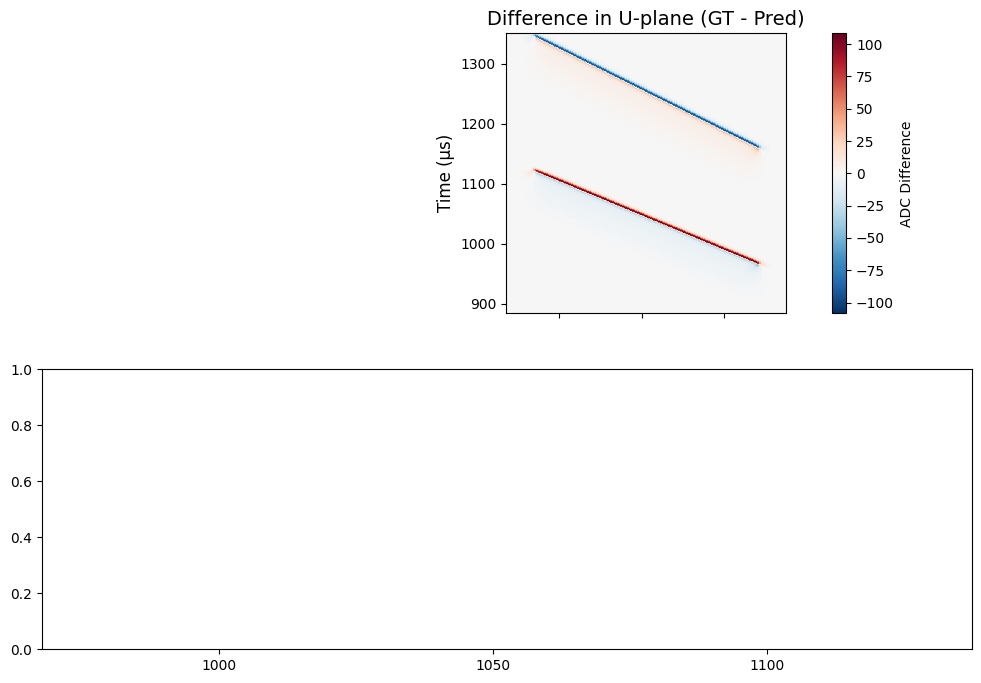

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), facecolor='white'
                       , sharex=True)
im0 = ax[0].imshow(diff_U.T, aspect='auto', origin='lower',
                   extent=[0, diff_U.shape[0], 0, max_time],
                   cmap='RdBu_r', vmin=-np.max(np.abs(diff_U)), vmax=np.max(np.abs(diff_U)),
                   interpolation='nearest')
ax[0].set_title('Difference in U-plane (GT - Pred)', fontsize=14)
ax[0].set_ylabel('Time (μs)', fontsize=12)
ax[0].set_xlim(plane_xlim[0])
ax[0].set_ylim(plane_ylim[0])
ax[0].set_box_aspect(1)
fig.colorbar(im0, ax=ax[0], label='ADC Difference') 

In [23]:
gt_U_plane.min(), pred_U_plane.min()

(np.float32(-96.64041), np.float32(-108.33018))

In [24]:
gt_Y_plane.min(), pred_Y_plane.min()

(np.float32(-9.096818), np.float32(-9.882255))